# Signal preprocessing

Load the observed signal, align the merger to $t=0$, and estimate the noise floor.

## Scientific method



The strain is analysed as a sampled time series. The merger reference time is defined operationally as the sample with minimum strain, which is appropriate for this simulated signal and gives a reproducible phase origin. The post-merger tail is then used as a noise-only window; its mean and standard deviation provide a simple Gaussian noise scale for later inference.

In [ ]:
from pathlib import Path

import sys



import matplotlib.pyplot as plt



PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / 'data').exists():

    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))



from gravitational_wave_mcmc import align_to_merger, estimate_noise, load_waveform

Samples: 636
Noise mean: 9.621e-25
Noise standard deviation: 5.062e-23


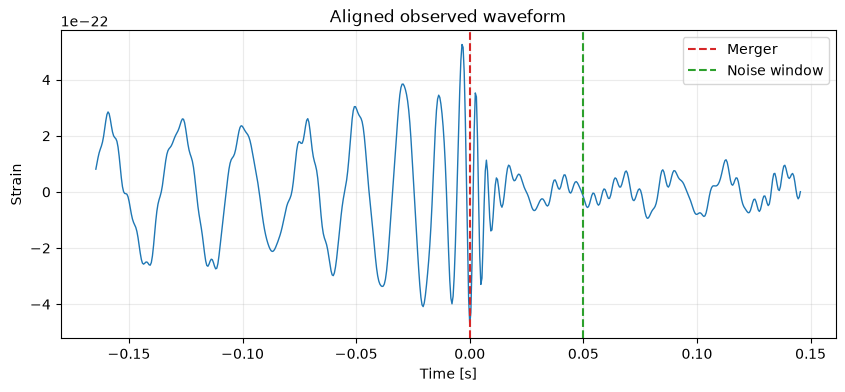

In [3]:
#Load and align the observed waveform
observed = load_waveform(PROJECT_ROOT / 'data' / 'raw' / 'Observedwaveform.csv')
aligned = align_to_merger(observed)
noise_mean, noise_std = estimate_noise(aligned, start_time=0.05)

#Print basic information about the aligned waveform and noise statistics
print(f'Samples: {aligned.time.size}')
print(f'Noise mean: {noise_mean:.3e}')
print(f'Noise standard deviation: {noise_std:.3e}')

#Plot the aligned waveform with merger and noise window markers
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(aligned.time, aligned.strain, lw=1)
ax.axvline(0, color='tab:red', ls='--', label='Merger')
ax.axvline(0.05, color='tab:green', ls='--', label='Noise window')
ax.set(xlabel='Time [s]', ylabel='Strain', title='Aligned observed waveform')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Interpretation



The aligned signal has its merger at $t=0$ and the waveform amplitude decays into a lower-amplitude tail. Treating samples after $0.05\,\mathrm{s}$ as noise is a modelling choice, not a physical boundary; it should be revisited for a different detector or event. The estimated standard deviation is therefore a data-driven uncertainty scale for this example, not a universal detector sensitivity.